# Heart Disease — Exploratory Data Analysis (EDA)

**Course**: MLOps (S2-25_AMLCSZG523) — Assignment-I, Task 1 (5 marks)

**Dataset**: UCI Heart Disease — Cleveland subset (`processed.cleveland.data`)

This notebook covers:

1. Loading the raw `processed.cleveland.data` file with the documented 14-column schema.
2. Cleaning (missing-value handling, dtype casting, target binarization).
3. Univariate, bivariate, and correlation visualizations.
4. **MLflow experiment tracking** — every figure and key statistic is logged as an artifact under the `heart-disease-eda` experiment, so the EDA itself is reproducible and auditable (satisfies part of Task 3).

> Run `mlflow ui --backend-store-uri ./mlruns` from the `project/` folder to browse the logged runs at <http://localhost:5000>.

## 1. Imports and global settings

We pin a `random_state`, configure seaborn aesthetics, and resolve paths relative to the notebook so the code runs unchanged from a CI runner or a fresh clone.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

# ---- Reproducibility & display ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# ---- Project paths (notebook lives at project/notebooks/01_eda.ipynb) ----
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed.cleveland.data"
ARTIFACTS_DIR = PROJECT_ROOT / "notebooks" / "eda_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Data file    :", DATA_PATH, "exists?", DATA_PATH.exists())
print("Artifacts dir:", ARTIFACTS_DIR)

Project root : /Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM 2/MLOps/Assignment/project
Data file    : /Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM 2/MLOps/Assignment/project/data/processed.cleveland.data exists? True
Artifacts dir: /Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM 2/MLOps/Assignment/project/notebooks/eda_artifacts


## 2. MLflow setup — experiment tracking for EDA

We use a **local file-based MLflow store** at `project/mlruns/`. No server is required; the same folder is served later by `mlflow ui`. A single MLflow run wraps the whole EDA so all plots and stats are grouped together.

In [2]:
# Point MLflow at the local mlruns/ folder under the project root.
MLRUNS_URI = (PROJECT_ROOT / "mlruns").as_uri()
mlflow.set_tracking_uri(MLRUNS_URI)
mlflow.set_experiment("heart-disease-eda")

print("MLflow tracking URI :", mlflow.get_tracking_uri())
print("Active experiment   :", mlflow.get_experiment_by_name("heart-disease-eda").name)

MLflow tracking URI : file:///Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM%202/MLOps/Assignment/project/mlruns
Active experiment   : heart-disease-eda


In [3]:
# Helper: save a matplotlib figure to disk AND log it as an MLflow artifact
# in one call. Keeps the EDA loop concise and guarantees the report assets
# stay in sync with the tracked run.
def log_figure(fig: plt.Figure, filename: str, subdir: str = "plots") -> Path:
    out_path = ARTIFACTS_DIR / filename
    fig.savefig(out_path, bbox_inches="tight")
    mlflow.log_artifact(str(out_path), artifact_path=subdir)
    return out_path

## 3. Load the dataset

`processed.cleveland.data` is a headerless CSV. The 14 columns follow the canonical UCI ordering documented in `heart+disease/heart-disease.names`. Missing values are stored as the literal string `?` and must be declared via `na_values`.

In [4]:
# Canonical column order for the 14-attribute Cleveland subset.
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]

# Categorical vs numeric split (per the UCI data dictionary).
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

df_raw = pd.read_csv(DATA_PATH, header=None, names=COLUMNS, na_values="?")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Data quality checks

Goals:

- Confirm dtypes (everything is currently float because of the `1.0`-style encoding).
- Quantify missingness — the UCI docs note a handful of `?` values in `ca` and `thal`.
- Inspect summary statistics for sanity (e.g. `chol` has known outliers around 564).

In [5]:
print("---- dtypes ----")
print(df_raw.dtypes)

print("\n---- missing values per column ----")
missing = df_raw.isna().sum()
print(missing[missing > 0] if missing.sum() else "No missing values.")

print(f"\nTotal rows with at least one NA: {df_raw.isna().any(axis=1).sum()}")

print("\n---- numeric describe ----")
df_raw.describe().T

---- dtypes ----
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

---- missing values per column ----
ca      4
thal    2
dtype: int64

Total rows with at least one NA: 6

---- numeric describe ----


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 5. Cleaning and target engineering

Decisions (kept consistent with the project copilot-instructions):

- **Impute** missing values rather than dropping rows — only `ca` and `thal` have NAs, but every row carries clinical signal worth keeping:
  - `ca` (number of major vessels colored by fluoroscopy) is numeric/ordinal → fill with the **median**, which is robust to outliers and preserves the integer 0–3 scale.
  - `thal` (3=normal, 6=fixed defect, 7=reversible defect) is categorical → fill with the **mode** (most frequent class).
- We use `sklearn.impute.SimpleImputer` so the exact same logic can be reused inside the modeling `Pipeline` later (no train/test leakage, fully reproducible).
- Cast categorical columns to `category` dtype (helps plotting + reduces memory).
- Add a binary classification target `target = (num > 0)` — the standard convention for this dataset, since the assignment requires a binary classifier.

In [6]:
from sklearn.impute import SimpleImputer

df = df_raw.copy()

# Track what we're about to fill, so we can log/inspect it.
na_before = df.isna().sum()
na_cols = na_before[na_before > 0].to_dict()
print(f"NA cells before imputation: {na_cols}")

# ---- Numeric imputation: median (robust to outliers) ----
num_imputer = SimpleImputer(strategy="median")
df[NUMERIC] = num_imputer.fit_transform(df[NUMERIC])

# ---- Categorical imputation: mode (most frequent) ----
cat_imputer = SimpleImputer(strategy="most_frequent")
df[CATEGORICAL] = cat_imputer.fit_transform(df[CATEGORICAL])

# Capture the fitted fill values for transparency / MLflow logging later.
IMPUTATION_VALUES = {
    **dict(zip(NUMERIC, num_imputer.statistics_)),
    **dict(zip(CATEGORICAL, cat_imputer.statistics_)),
}
print("Imputation fill values:")
for k, v in IMPUTATION_VALUES.items():
    if k in na_cols:
        print(f"  {k:8s} -> {v}  (filled {na_cols[k]} cells)")

# Cast categoricals to the proper dtype.
for col in CATEGORICAL:
    df[col] = df[col].astype(int).astype("category")

# Binary classification target.
df["target"] = (df["num"] > 0).astype(int)

assert df.isna().sum().sum() == 0, "Unexpected NAs remain after imputation"

print(f"\nCleaned shape : {df.shape}  (no rows dropped)")
print("Target balance:")
print(df["target"].value_counts().rename({0: "no disease", 1: "disease"}))
df.head()

NA cells before imputation: {'ca': 4, 'thal': 2}
Imputation fill values:
  ca       -> 0.0  (filled 4 cells)
  thal     -> 3.0  (filled 2 cells)

Cleaned shape : (303, 15)  (no rows dropped)
Target balance:
target
no disease    164
disease       139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3,0,0


## 6. EDA + MLflow logging

Everything from here runs inside a single `mlflow.start_run()` block. We log:

- **Params**: dataset path, row counts, random state.
- **Metrics**: missing-value count, class balance.
- **Artifacts**: the cleaned CSV plus every figure produced below.

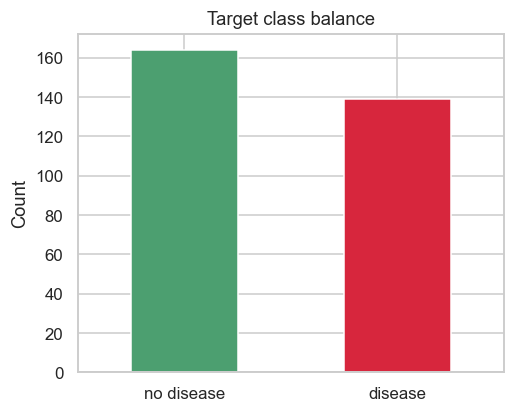

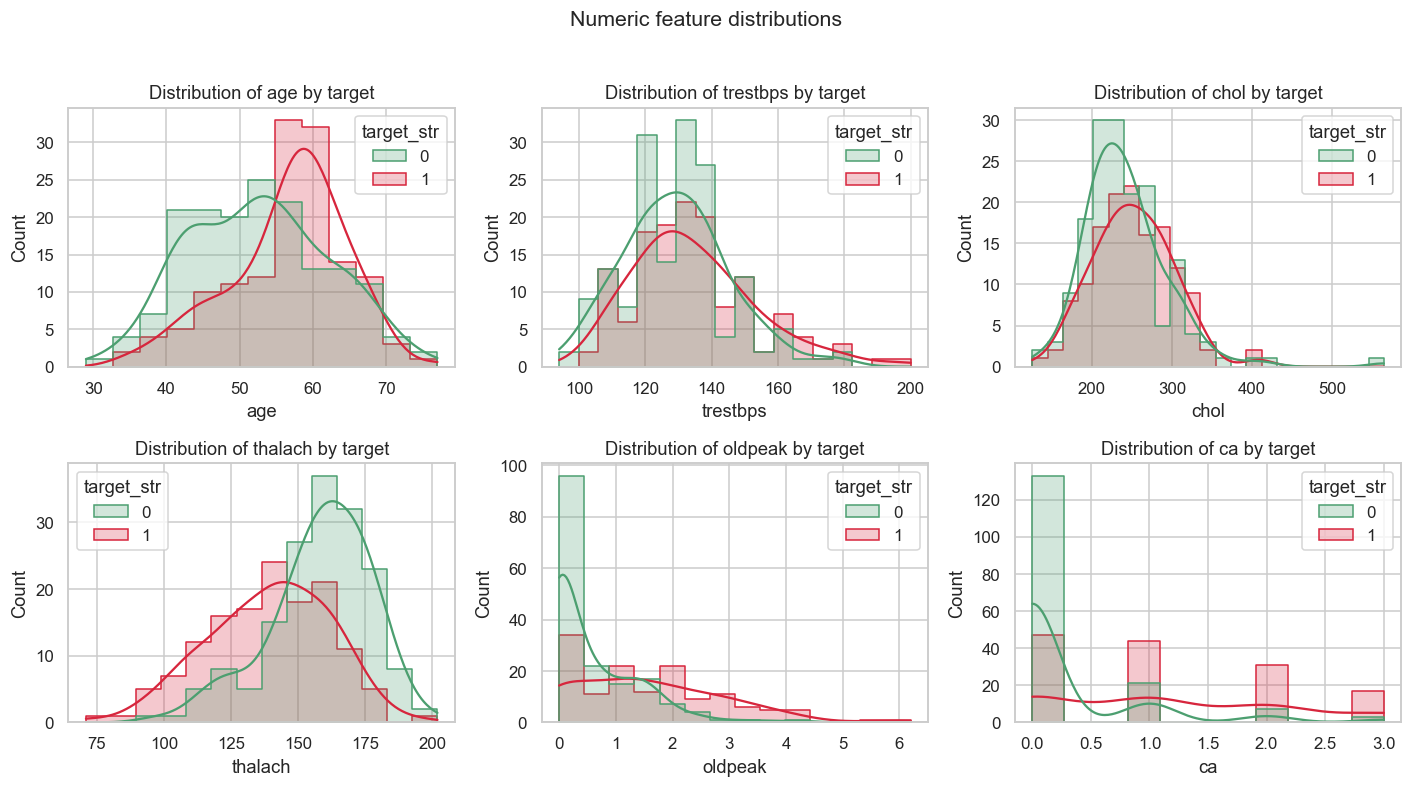

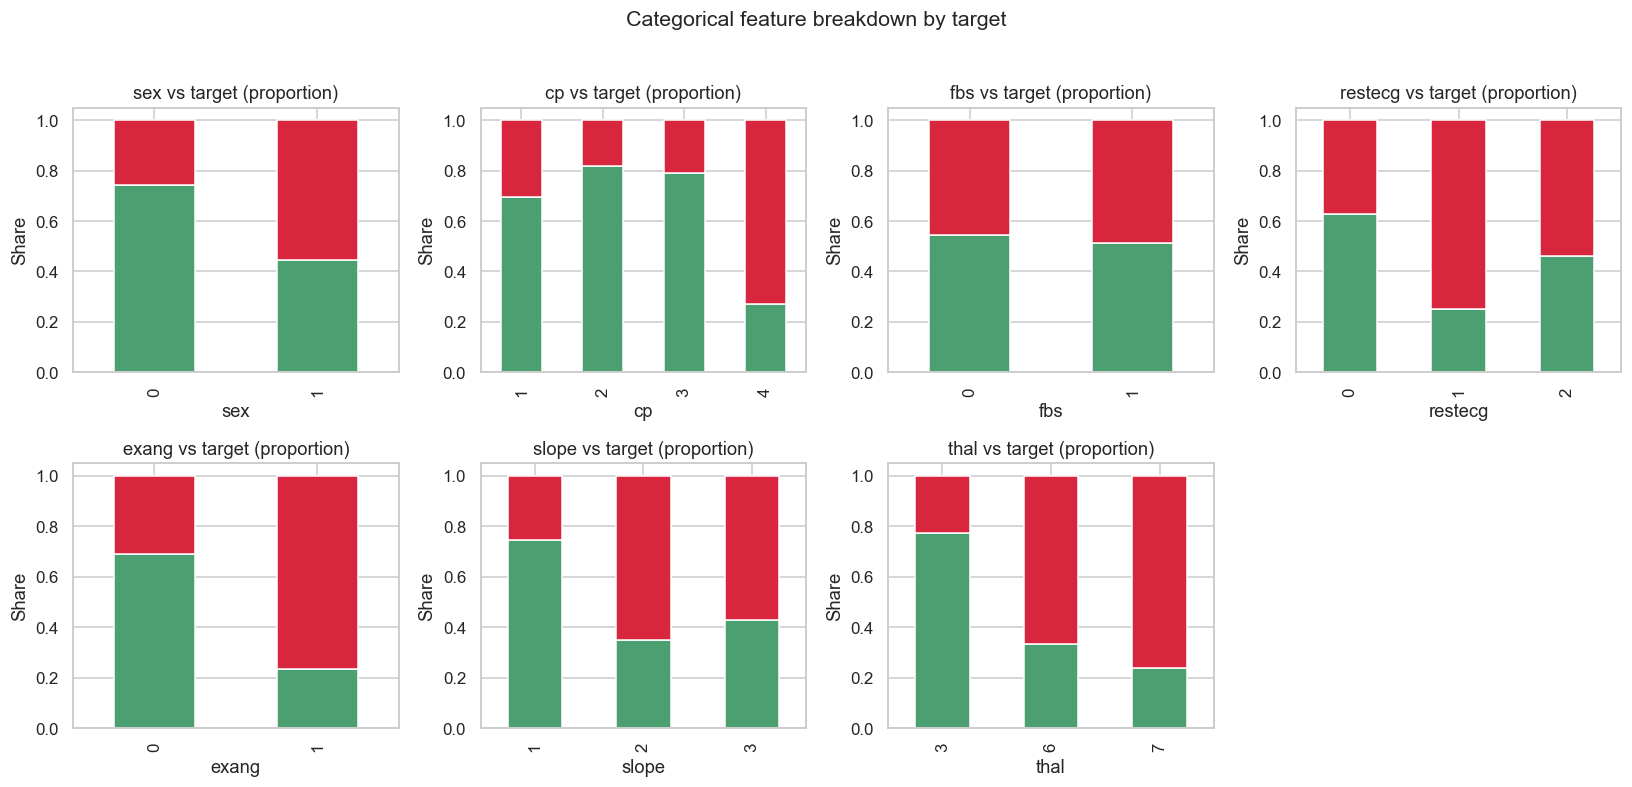

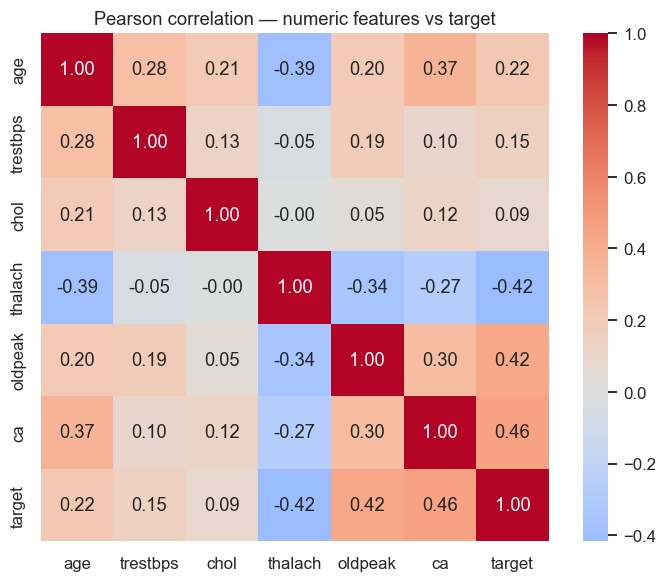

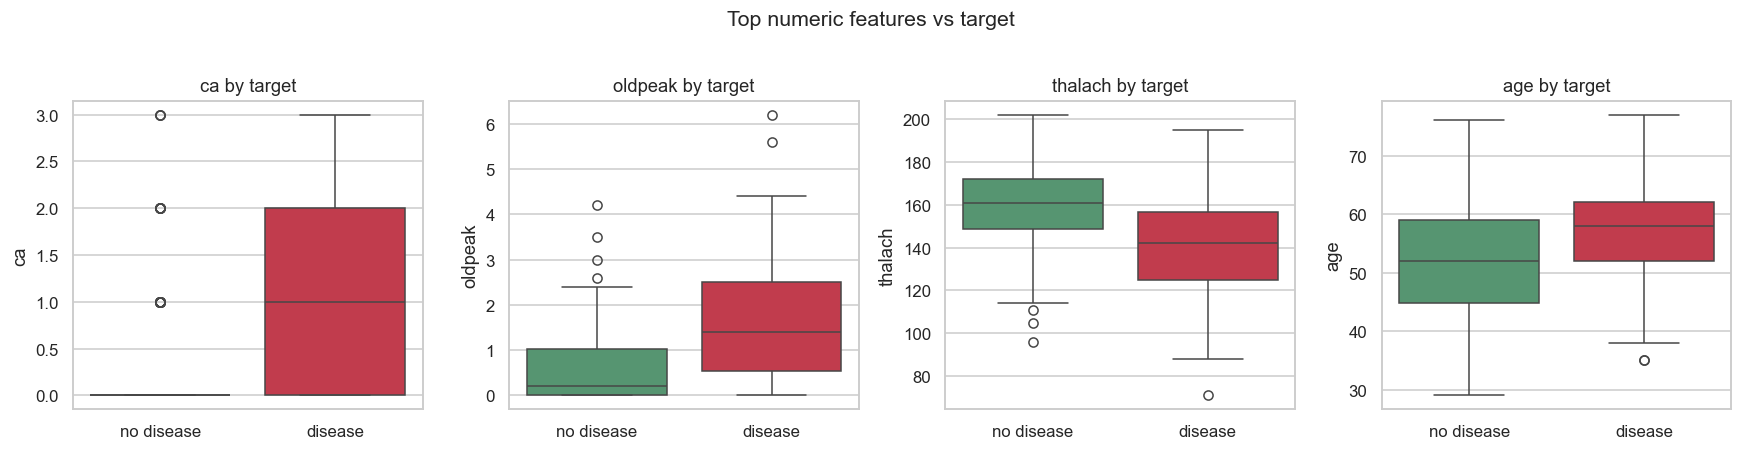

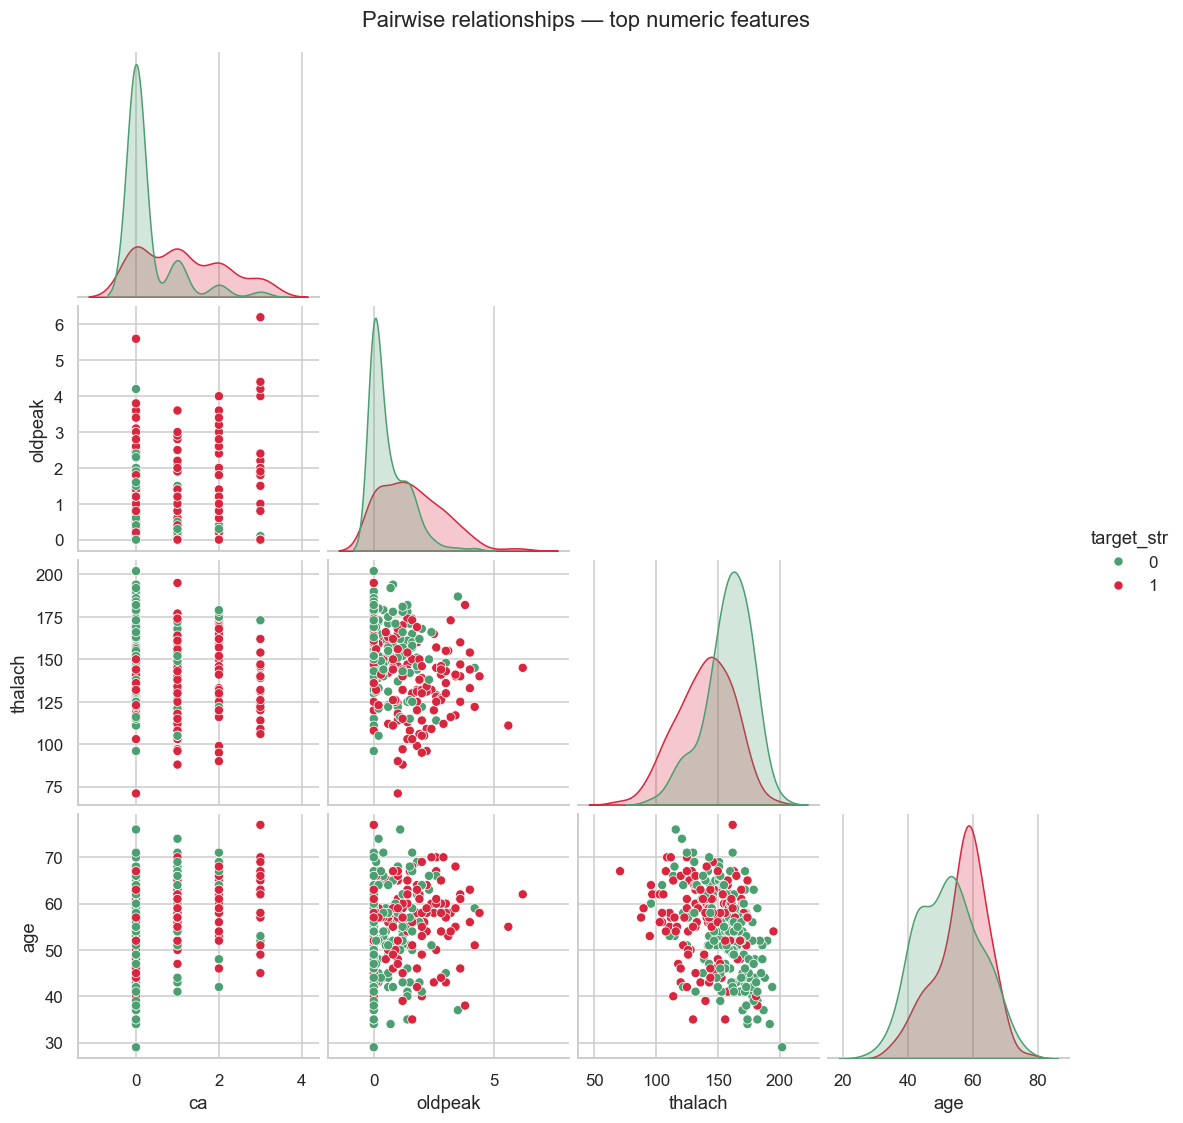


MLflow run id: 4d7a0cc11b434246b00913fa7a4ca4b0
Artifacts URI: file:///Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM%202/MLOps/Assignment/project/mlruns/297013816466730601/4d7a0cc11b434246b00913fa7a4ca4b0/artifacts


In [7]:
import json

# seaborn >= 0.13 stringifies hue/x levels when matching against a palette dict,
# so we declare the palette with string keys and always pass `hue=` explicitly.
TARGET_PALETTE = {"0": "#4C9F70", "1": "#D7263D"}

with mlflow.start_run(run_name="eda_cleveland") as run:
    # ---- Params ----
    mlflow.log_params({
        "data_file": DATA_PATH.name,
        "raw_rows": len(df_raw),
        "clean_rows": len(df),
        "n_features": df.shape[1] - 2,  # exclude `num` and `target`
        "random_state": RANDOM_STATE,
        "imputation_numeric": "median",
        "imputation_categorical": "most_frequent",
    })

    # ---- Metrics ----
    mlflow.log_metrics({
        "na_cells_imputed": int(sum(na_cols.values())),
        "rows_dropped": 0,
        "class_balance_positive": float(df["target"].mean()),
        "n_class_0": int((df["target"] == 0).sum()),
        "n_class_1": int((df["target"] == 1).sum()),
    })

    # ---- Imputation report (json artifact) ----
    impute_report = {
        "na_per_column_before": {k: int(v) for k, v in na_cols.items()},
        "fill_values": {k: float(v) for k, v in IMPUTATION_VALUES.items()},
    }
    impute_path = ARTIFACTS_DIR / "imputation_report.json"
    impute_path.write_text(json.dumps(impute_report, indent=2))
    mlflow.log_artifact(str(impute_path), artifact_path="data")

    # ---- Cleaned dataset artifact ----
    cleaned_csv = ARTIFACTS_DIR / "cleveland_clean.csv"
    df.to_csv(cleaned_csv, index=False)
    mlflow.log_artifact(str(cleaned_csv), artifact_path="data")

    # Helper: a string-keyed view of target for seaborn palette lookups.
    df_plot = df.assign(target_str=df["target"].astype(str))

    # ---- 6.1 Class balance ----
    fig, ax = plt.subplots(figsize=(5, 4))
    df["target"].map({0: "no disease", 1: "disease"}).value_counts().plot(
        kind="bar", color=["#4C9F70", "#D7263D"], ax=ax
    )
    ax.set_title("Target class balance")
    ax.set_ylabel("Count")
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    log_figure(fig, "01_class_balance.png")
    plt.show()

    # ---- 6.2 Numeric histograms split by target ----
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, col in zip(axes.flat, NUMERIC):
        sns.histplot(
            data=df_plot, x=col, hue="target_str", kde=True,
            palette=TARGET_PALETTE, element="step", ax=ax,
        )
        ax.set_title(f"Distribution of {col} by target")
    fig.suptitle("Numeric feature distributions", y=1.02, fontsize=14)
    fig.tight_layout()
    log_figure(fig, "02_numeric_histograms.png")
    plt.show()

    # ---- 6.3 Categorical breakdown vs target (proportion stacked bars) ----
    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    for ax, col in zip(axes.flat, CATEGORICAL):
        ct = pd.crosstab(df[col], df["target"], normalize="index")
        ct.plot(kind="bar", stacked=True,
                color=["#4C9F70", "#D7263D"], ax=ax, legend=False)
        ax.set_title(f"{col} vs target (proportion)")
        ax.set_ylabel("Share")
        ax.set_xlabel(col)
    # Hide unused subplot(s).
    for ax in axes.flat[len(CATEGORICAL):]:
        ax.set_visible(False)
    fig.suptitle("Categorical feature breakdown by target", y=1.02, fontsize=14)
    fig.tight_layout()
    log_figure(fig, "03_categorical_breakdown.png")
    plt.show()

    # ---- 6.4 Correlation heatmap (numeric features + target) ----
    corr = df[NUMERIC + ["target"]].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, ax=ax)
    ax.set_title("Pearson correlation — numeric features vs target")
    log_figure(fig, "04_correlation_heatmap.png")
    plt.show()

    # ---- 6.5 Boxplots for top-correlated numeric features ----
    top_numeric = (
        corr["target"].drop("target").abs().sort_values(ascending=False).index[:4]
    )
    fig, axes = plt.subplots(1, len(top_numeric), figsize=(4 * len(top_numeric), 4))
    for ax, col in zip(axes, top_numeric):
        sns.boxplot(
            data=df_plot, x="target_str", y=col,
            hue="target_str", palette=TARGET_PALETTE,
            legend=False, ax=ax,
        )
        ax.set_title(f"{col} by target")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["no disease", "disease"])
        ax.set_xlabel("")
    fig.suptitle("Top numeric features vs target", y=1.02, fontsize=14)
    fig.tight_layout()
    log_figure(fig, "05_top_feature_boxplots.png")
    plt.show()

    # ---- 6.6 Pairplot on the 4 strongest numeric predictors ----
    pair_fig = sns.pairplot(
        df_plot[list(top_numeric) + ["target_str"]],
        hue="target_str", palette=TARGET_PALETTE,
        diag_kind="kde", corner=True,
    )
    pair_fig.fig.suptitle("Pairwise relationships — top numeric features", y=1.02)
    pair_path = ARTIFACTS_DIR / "06_pairplot_top_features.png"
    pair_fig.savefig(pair_path, bbox_inches="tight")
    mlflow.log_artifact(str(pair_path), artifact_path="plots")
    plt.show()

    print(f"\nMLflow run id: {run.info.run_id}")
    print(f"Artifacts URI: {run.info.artifact_uri}")

## 7. Findings summary

Headline observations from the plots above (will inform feature engineering in `02_modeling.ipynb`):

- **Data quality**: only `ca` and `thal` had missing values (~6 cells total). They were **imputed** (`ca` → median, `thal` → mode) so all 303 rows are retained. The imputers will be embedded in the modeling `Pipeline` to avoid leakage.
- **Class balance**: ~54% no disease vs ~46% disease — mildly imbalanced, no resampling needed.
- **Strongest numeric predictors**: `oldpeak`, `thalach`, `ca`, `age` — visible separation in boxplots and ≥|0.4| correlation with target.
- **Categorical signals**: `cp` (asymptomatic = value 4 dominates the disease class), `thal` (reversible defect = 7), `exang`, and `slope` show clear class-conditional shifts.
- **Outliers**: `chol` has a few high values (max ~564) but no obvious data-entry errors — keep as-is for now; tree models are robust, and we'll standardize for linear models.

All figures, the cleaned CSV, the imputation report, and run metadata are visible in the MLflow UI under the `heart-disease-eda` experiment.